In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib_venn import venn3

import matplotlib.pyplot as plt

In [3]:
PATH = Path("../data/raw")

files = {
    "nodes": PATH / "nodes.csv",
    "streets": PATH / "streets.csv",
    "segments": PATH / "segments.csv",
    "status": PATH / "segment_status.csv",
    "train": PATH / "train.csv"
}

# Đọc dữ liệu

In [4]:
nodes_df = pd.read_csv(files["nodes"])
streets_df = pd.read_csv(files["streets"])
segments_df = pd.read_csv(files["segments"])
status_df = pd.read_csv(files["status"])
train_df = pd.read_csv(files["train"])

# Kiểu dữ liệu

In [5]:
nodes_df.dtypes

_id       int64
long    float64
lat     float64
dtype: object

In [6]:
streets_df.dtypes

_id               int64
level             int64
max_velocity    float64
name                str
type                str
dtype: object

In [7]:
segments_df.dtypes

_id               int64
created_at          str
updated_at          str
s_node_id         int64
e_node_id         int64
length            int64
street_id         int64
max_velocity    float64
street_level      int64
street_name         str
street_type         str
dtype: object

In [8]:
status_df.dtypes

_id           int64
updated_at      str
segment_id    int64
velocity      int64
dtype: object

In [9]:
train_df.dtypes

_id               int64
segment_id        int64
date                str
weekday           int64
period              str
LOS                 str
s_node_id         int64
e_node_id         int64
length            int64
street_id         int64
max_velocity    float64
street_level      int64
street_name         str
street_type         str
long_snode      float64
lat_snode       float64
long_enode      float64
lat_enode       float64
dtype: object

# Thống kê mô tả

In [10]:
nodes_df.describe()

,_id,long,lat
count,5.779670e+05,577967.000000,577967.000000
mean,4.315269e+09,106.703700,10.808332
std,1.887984e+09,0.069665,0.049736
min,3.663672e+08,106.536005,10.676001
25%,2.964647e+09,106.655452,10.772766
50%,5.627164e+09,106.714413,10.824470
75%,5.737770e+09,106.747359,10.845259
max,6.205236e+09,106.867994,10.888998


In [11]:
streets_df.describe()

,_id,level,max_velocity
count,5.553000e+03,5553.000000,987.000000
mean,3.457455e+08,3.199712,58.232016
std,2.017849e+08,0.991818,16.046644
min,3.109679e+07,1.000000,10.000000
25%,1.991616e+08,3.000000,50.000000
50%,3.215683e+08,4.000000,60.000000
75%,5.682871e+08,4.000000,60.000000
max,6.583281e+08,4.000000,120.000000


In [12]:
segments_df.describe()

,_id,s_node_id,e_node_id,length,street_id,max_velocity,street_level
count,84633.000000,8.463300e+04,8.463300e+04,84633.000000,8.463300e+04,9871.000000,84633.000000
mean,42316.000000,3.674041e+09,3.672725e+09,41.818050,2.866904e+08,54.503596,3.500006
std,24431.587003,2.039756e+09,2.040056e+09,52.692336,2.085526e+08,16.553367,0.841222
min,0.000000,3.663672e+08,3.663672e+08,0.000000,3.109679e+07,10.000000,1.000000
25%,21158.000000,2.078951e+09,2.078951e+09,13.000000,3.511357e+07,40.000000,3.000000
50%,42316.000000,4.068031e+09,4.068031e+09,27.000000,2.517313e+08,60.000000,4.000000
75%,63474.000000,5.748273e+09,5.748270e+09,52.000000,4.693276e+08,60.000000,4.000000
max,84632.000000,6.175932e+09,6.175932e+09,1622.000000,6.583281e+08,120.000000,4.000000


In [13]:
status_df.describe()

,_id,segment_id,velocity
count,90938.000000,90938.000000,90938.000000
mean,45468.500000,40376.030009,20.754844
std,26251.683727,22415.108133,19.567112
min,0.000000,26.000000,0.000000
25%,22734.250000,21263.000000,2.000000
50%,45468.500000,41875.000000,17.000000
75%,68202.750000,58440.750000,34.000000
max,90937.000000,84535.000000,200.000000


In [14]:
train_df.describe()

,_id,segment_id,weekday,s_node_id,e_node_id,length,street_id,max_velocity,street_level,long_snode,lat_snode,long_enode,lat_enode
count,33441.000000,33441.000000,33441.000000,3.344100e+04,3.344100e+04,33441.000000,3.344100e+04,4946.000000,33441.000000,33441.000000,33441.000000,33441.000000,33441.000000
mean,16720.000000,41014.936575,2.915254,3.528928e+09,3.582345e+09,48.709010,2.715539e+08,59.299434,3.029993,106.670354,10.804326,106.670334,10.804352
std,9653.729512,22489.675329,2.329021,2.008085e+09,2.014716e+09,52.251062,1.908930e+08,14.172472,1.022137,0.041887,0.040358,0.041868,0.040377
min,0.000000,26.000000,0.000000,3.663674e+08,3.663678e+08,0.000000,3.257582e+07,10.000000,1.000000,106.537476,10.676452,106.537776,10.676467
25%,8360.000000,21967.000000,1.000000,2.079964e+09,2.079965e+09,17.000000,5.588046e+07,50.000000,2.000000,106.649521,10.772135,106.649478,10.772131
50%,16720.000000,41654.000000,3.000000,3.771416e+09,4.066314e+09,34.000000,2.420036e+08,60.000000,3.000000,106.664687,10.797884,106.664704,10.797776
75%,25080.000000,58456.000000,5.000000,5.738236e+09,5.748445e+09,63.000000,4.082464e+08,60.000000,4.000000,106.685096,10.837117,106.685212,10.837388
max,33440.000000,84535.000000,6.000000,6.175932e+09,6.175932e+09,1011.000000,6.565625e+08,120.000000,4.000000,106.867740,10.888965,106.867654,10.888993


# Kiểm tra dữ liệu thừa thiếu

In [15]:
print(nodes_df.duplicated().sum())
nodes_df.isnull().sum()

0


_id     0
long    0
lat     0
dtype: int64

In [16]:
print(streets_df.duplicated().sum())
streets_df.isnull().sum()

0


_id                0
level              0
max_velocity    4566
name            1605
type               0
dtype: int64

In [17]:
print(segments_df.duplicated().sum())
segments_df.isnull().sum()

0


_id                 0
created_at          0
updated_at          0
s_node_id           0
e_node_id           0
length              0
street_id           0
max_velocity    74762
street_level        0
street_name       152
street_type         0
dtype: int64

In [18]:
print(status_df.duplicated().sum())
status_df.isnull().sum()

0


_id           0
updated_at    0
segment_id    0
velocity      0
dtype: int64

In [19]:
print(train_df.duplicated().sum())
train_df.isnull().sum()

0


_id                 0
segment_id          0
date                0
weekday             0
period              0
LOS                 0
s_node_id           0
e_node_id           0
length              0
street_id           0
max_velocity    28495
street_level        0
street_name         1
street_type         0
long_snode          0
lat_snode           0
long_enode          0
lat_enode           0
dtype: int64

# Kiểm tra tập cha - con

## Node

In [ ]:
# Kiểm tra số bản ghi = số lượng id
print(len(nodes_df["_id"]) == len(nodes_df))

True


In [21]:
n_nodes = len(nodes_df)
print(n_nodes)

577967


### Số nodes có trong segments.csv

In [22]:
# s_node_id
s_segment_nodes = segments_df["s_node_id"].unique()
n_s_segment_nodes = len(s_segment_nodes)
print("Số node đầu của segment:", n_s_segment_nodes)
print("Tỉ lệ node đầu segments.csv có trong nodes.csv:", n_s_segment_nodes/n_nodes)

# e_node_id
e_segment_nodes = segments_df["e_node_id"].unique()
n_e_segment_nodes = len(e_segment_nodes)
print("\nSố node đích của segment:", n_e_segment_nodes)
print("Tỉ lệ node đầu segments.csv có trong nodes.csv:", n_e_segment_nodes/n_nodes)


Số node đầu của segment: 52384
Tỉ lệ node đầu segments.csv có trong nodes.csv: 0.0906349324442399

Số node đích của segment: 52386
Tỉ lệ node đầu segments.csv có trong nodes.csv: 0.09063839284941874


### Số nodes có trong train.csv

In [23]:
# s_node_id
s_train_nodes = train_df["s_node_id"].unique()
n_s_train_nodes = len(s_train_nodes)
print("Số node đầu của train:", n_s_train_nodes)
print("Tỉ lệ node đầu train.csv có trong nodes.csv:", n_s_train_nodes/n_nodes)

# e_node_id
e_train_nodes = train_df["e_node_id"].unique()
n_e_train_nodes = len(e_train_nodes)
print("\nSố node đích của train:", n_e_train_nodes)
print("Tỉ lệ node đầu train.csv có trong nodes.csv:", n_e_train_nodes/n_nodes)

Số node đầu của train: 8430
Tỉ lệ node đầu train.csv có trong nodes.csv: 0.014585607828820677

Số node đích của train: 8427
Tỉ lệ node đầu train.csv có trong nodes.csv: 0.014580417221052413


### Số nodes trong train.csv có trong segments.csv

In [31]:
train_df.columns

Index(['_id', 'segment_id', 'date', 'weekday', 'period', 'LOS', 's_node_id',
       'e_node_id', 'length', 'street_id', 'max_velocity', 'street_level',
       'street_name', 'street_type', 'long_snode', 'lat_snode', 'long_enode',
       'lat_enode'],
      dtype='str')

In [ ]:
# s_node_id
inter_s_node_train_segment = train_df[
    train_df["s_node_id"]
    .isin(
        segments_df["s_node_id"].unique()
    )
]["s_node_id"].unique()
print(len(inter_s_node_train_segment))

8430


In [36]:
# e_node_id
inter_e_node_train_segment = train_df[
    train_df["e_node_id"]
    .isin(
        segments_df["e_node_id"].unique()
    )
]["e_node_id"].unique()
print(len(inter_e_node_train_segment))

8427


## Street

In [25]:
# Kiểm tra số lượng bản ghi street = unique _id?
print(len(streets_df) == len(streets_df["_id"].unique()))

True


In [26]:
n_streets = len(streets_df)
streets = streets_df["_id"].unique()
print(n_streets)

5553


### Số street có trong segments.csv

In [27]:
streets_segments = segments_df["street_id"].unique()
n_streets_segments = len(streets_segments)
print("Số lượng street trong segments.csv:", n_streets_segments)
print("Tỉ lệ street segments.csv so với streets", n_streets_segments/n_streets)

Số lượng street trong segments.csv: 5539
Tỉ lệ street segments.csv so với streets 0.9974788402665226


### Số streets có trong train.csv

In [28]:
streets_train = train_df["street_id"].unique()
n_streets_train = len(streets_train)
print("Số lượng street trong train.csv:", n_streets_train)
print("Tỉ lệ street trong train.csv so với streets.csv:", n_streets_train/n_streets)

Số lượng street trong train.csv: 1967
Tỉ lệ street trong train.csv so với streets.csv: 0.35422294255357467


### Số streets trong train có trong segments

In [29]:
inter_streets_segments_train = train_df[
    train_df["street_id"]
    .isin(
        segments_df["street_id"]
    )
]["street_id"].unique()
print(len(inter_streets_segments_train))

1967


### Kết luận

Text(0.5, 1.0, 'Biểu đồ Vengram thể hiện số lượng streets trong 3 dataset')

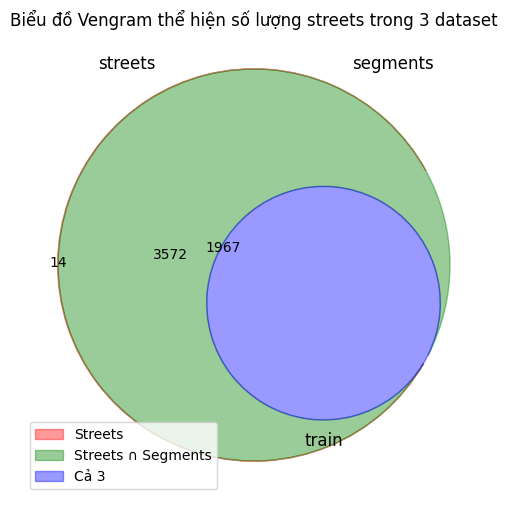

In [30]:
plt.figure(figsize=(6, 6))
venn = venn3(
    subsets=[set(streets), set(streets_segments), set(streets_train)],
    set_labels=('streets', 'segments', 'train')
) 
venn.get_patch_by_id('100').set_color('red')
venn.get_patch_by_id("110").set_color("green")
venn.get_patch_by_id("111").set_color("blue")

labels = {
    '100': 'Streets',
    '110': 'Streets ∩ Segments',
    '111': 'Cả 3'
}

handles = []
for k, v in labels.items():
    patch = venn.get_patch_by_id(k)
    if patch:
        patch.set_label(v)
        handles.append(patch)

plt.legend(handles=handles, loc='best')
plt.title("Biểu đồ Vengram thể hiện số lượng streets trong 3 dataset")

# Kiểm tra node ref